<a href="https://colab.research.google.com/github/alveslucas60-aluno/MN-Projetos/blob/main/Determinar_arremesso_ideal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Determinação do ângulo e velocidade ideais para arremessos no basquete através de métodos numéricos utilizando interpolação por spline cúbica.

 O código em questão tem como objetivo encontrar ângulos e velocidades ideais para arremessos de atletas de basquete de diferentes alturas utilizando métodos numéricos.
 Tendo como base física conceitos de lançamento obliquo funcionando em conjunto com interpolação para determinar a trajetória ideal do arremesso.

Um atleta com altura: 2.01 m, para um arrremesso eficiente, temos:
-------------------------------------------------
Ângulo ideal: 59°
Velocidade ideal: 7.40 m/s²
Erro: 0.0009 
-------------------------------------------------

Integral de referência: 20.472463

Solução para 10 partes é: 20.252205
Erro respectivo: 0.220258

Solução para 100 partes é: 20.449988
Erro respectivo: 0.022475

Solução para 1000 partes é: 20.470251
Erro respectivo: 0.002212

Solução para 10000 partes é: 20.472242
Erro respectivo: 0.000221

Precisão desejada: erro < 0.001
Atingida com: 10000 partes
Área abaixo da curva: 20.472242 m²
-------------------------------------------------

Raiz encontrada por Newton-Raphson: 4.569372, com 2 iterações
 


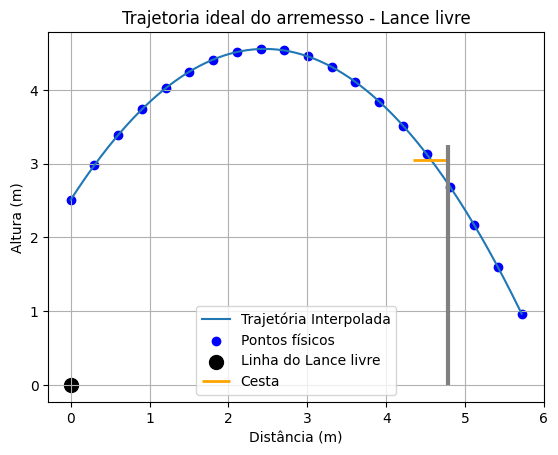

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy import integrate

#Definições para Simpson Composto 3/8:
# Determinar referência
def Referencia(a,b,f):                           # Refêrencia da integral da função para método de Simpson
    g,e=integrate.quad(f,a,b)
    print(f'\nIntegral de referência: {round(g,6)}')
    return g

# Simpson 3/8 - Área abaixo da curva
def SimpsonComposto_3_8(a,b,f,ref,Ns:list=[10,100,1000]):

    for N in Ns:

        N_aparente = N

        while (N%3)!=0:                          # Validar número ternário de intervalos
            N += 1
        h=(b-a)/N
        x=np.arange(a,(b+h),h)                   # Atualizar x em função de h intervalos
        p1,p2=0,0
        for i in (np.arange(1,N,3)):
            p1+=3*( f(x[i])+f(x[i+1]) )
        for i in (np.arange(4,N,3)):
            p2+=2*f(x[i])
        s1=(f(a) + p1 + p2 + f(b))*h*3/8
        erro = abs(ref-s1)                       # Definir erro
        print(f'\nSolução para {N_aparente} partes é: {round(s1,6)}')
        print(f'Erro respectivo: {round(erro,6)}')

        if erro < 0.001:                         # Criterio de parada
            print('\nPrecisão desejada: erro < 0.001')
            print(f'Atingida com: {N_aparente} partes')
            print(f"Área abaixo da curva: {s1:.6f} m²")
            break
    return s1

# Definições para Newton-Raphson:
def f(x):                                       # Função (trajetoria interpolada - altura da cesta)
    return spline(x) - y_cesta

def df(x):                                      # Derivada da função - Newton Raphson
    return derivada_spline(x)

def newton(f, df, x0):
    x = x0
    for k in range(100):
        x_new = x - f(x)/df(x)
        if abs(x_new-x) < 1e-6:
            return x_new, k+1
        x = x_new
    return x, k+1


# Código Main:

# Dados de entrada:
#v0 = 7.5                      # velocidade inicial
#angulo = 42                   # ângulo inicial
g = 9.83                       # gravidade (fórmula posição horizontal)
x_cesta = 4.57                 # distância - lance livre
y_cesta = 3.05                 # altura da cesta
altura_atleta = 2.01
h = altura_atleta + 0.50       # calculo de release considerando 0.50 para arremessos lance livre

# Listas:
lista_angulos = []             # listas para armazenamento de resultados calculados
lista_velocidades = []
lista_erros = []

# Otimização / Automação:
angulos = np.arange(40, 70, 1) # array p/ automatizar a entrada de dados
velocidades = np.arange(5, 10, 0.1)

for angulo in angulos:         # laço for p/ testar cada combinação com intuito de achar o índice que possue menor erro
  for v0 in velocidades:

      # Convesor de radianos para graus:             # exibir graus ao inves de rad
      conv_angulo = np.radians(angulo)

      # Base Fisica:
      vx = v0*np.cos(conv_angulo)                      # velocidade horizontal
      vy = v0*np.sin(conv_angulo)                      # velocidade vertical
      t = np.linspace(0, 1.5, 20)                      # discretização do tempo
      x = vx * t                                       # posição horizontal
      y = h + vy * t - (0.5 * g * t**2)                # posição vertical

      # Filtro dados:                                  # filtrar valores a baixo de 0
      filtro_dados = y >= 0
      x_filtrados = x[filtro_dados]
      y_filtrados = y[filtro_dados]

      # Spline Cubica:
      spline = CubicSpline(x_filtrados, y_filtrados)  # método de interpolação utilizado
      xg = np.linspace(0, max(x_filtrados), 300)      # distância interpolada
      yg = spline(xg)                                 # altura interpolada

      # Erro:
      altura_bola_cesta = spline(x_cesta)
      erro = abs(altura_bola_cesta - y_cesta)         # diferença entra a altura da bola e a cesta na mesma posição horizontal

      # Armazenamento nas listas:
      lista_angulos.append(angulo)                    # retornar todas as combinações obtidas para listas
      lista_velocidades.append(v0)
      lista_erros.append(erro)

# Analise de eficiência
menor_erro = min(lista_erros)                         # obter o índice que apresenta o menor erro relativo presente armazenado nas listas
indice = lista_erros.index(menor_erro)
angulo_ideal = lista_angulos[indice]                  # índice - ângulo
velocidade_ideal = lista_velocidades[indice]          # índice - velocidade

# Imprimir resultados:
print(f"Um atleta com altura: {altura_atleta :.2f} m, para um arrremesso eficiente, temos:")
print("-------------------------------------------------")
print(f"Ângulo ideal: {angulo_ideal :.0f}°")
print(f"Velocidade ideal: {velocidade_ideal :.2f} m/s²")
print(f"Erro: {menor_erro :.4f} ")
print("-------------------------------------------------")
# Arremesso ideal:
                                                      # refazer o processo com o índice na qual apresenta o menor erro
                                                      # respectivamente com o ângulo e velocidade ideal
# Fisica final:
conv_angulo = np.radians(angulo_ideal)
vx = velocidade_ideal * np.cos(conv_angulo)
vy = velocidade_ideal * np.sin(conv_angulo)
t = np.linspace(0, 1.5, 20)
x = vx * t
y = h + vy * t - (0.5 * g * t**2)

# Filtro final:
filtro_dados = y >= 0
x_filtrados = x[filtro_dados]
y_filtrados = y[filtro_dados]

# Spline final:
spline = CubicSpline(x_filtrados, y_filtrados)
xg = np.linspace(0, max(x_filtrados), 300)
yg = spline(xg)

# Dados Simpson:
fs = lambda x: spline(x)                            # fs= função para calcular simpson
a= min(x_filtrados)                                 # intervalos para integração
b= max(x_filtrados)
N= [10,100,1000,10000,100000]                       # quantidade de intervalos para integração

ref= Referencia (a,b,fs)                            # definir referência
area= SimpsonComposto_3_8(a,b,fs,ref,N)             # área para exibir resultados

# Dados Newton-Raphson:
derivada_spline = spline.derivative()               # derivada da função
x_new, it_new = newton(f, df, x_cesta)              # chamar a definição para Newton
print("-------------------------------------------------")
print(f"\nRaiz encontrada por Newton-Raphson: {x_new:.6f}, com {it_new} iterações\n ")

# Grafico:
plt.plot(xg, yg,label='Trajetória Interpolada')
plt.scatter(x_filtrados, y_filtrados,color='blue',label='Pontos físicos')
plt.scatter(x=0, y=0,color='black', s=100 , label='Linha do Lance livre')
plt.hlines(y_cesta,xmin=4.57-0.225,xmax=4.57+0.225,color='orange',linewidth=2, label = 'Cesta')
plt.vlines(x=4.78,ymin=0,ymax=3.25,linewidth=3,color='gray')

plt.xlabel('Distância (m)')
plt.ylabel('Altura (m)')
plt.title('Trajetoria ideal do arremesso - Lance livre')
plt.grid()
plt.legend()
plt.show()